**Libraries**

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df1 = pd.read_table('/content/movies.dat', header=None, delimiter='::')
df2 = pd.read_table('/content/ratings.dat', header=None, delimiter='::')
df3 = pd.read_table('/content/users.dat', header=None, delimiter='::')

<ipython-input-84-8798cd50a3de>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df1 = pd.read_table('/content/movies.dat', header=None, delimiter='::')
<ipython-input-84-8798cd50a3de>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df2 = pd.read_table('/content/ratings.dat', header=None, delimiter='::')
<ipython-input-84-8798cd50a3de>:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df3 = pd.read_table('/conte

In [85]:
df1

,0,1,2
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [86]:
df1.rename(columns = {0:'MovieID',
                         1:'Title',
                         2:'Genres'},
              inplace = True)

In [87]:
df2

,0,1,2,3
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [88]:
df2.rename(columns = {0:'UserID',
                         1:'MovieID',
                         2:'Rating',
                      3:'Timestamp'},
              inplace = True)

In [89]:
df1

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [90]:
df2

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [91]:
df3.rename(columns = {0:'UserID',
                         1:'Gender',
                         2:'Age',
                      3:'Occupation',
                      4:'Zip-code'},
              inplace = True)

In [92]:
df3

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


In [93]:
movie_ratings = df2.merge(df1, on='MovieID')
movie_ratings['Title'].value_counts()[0:10]

American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: Title, dtype: int64

In [94]:
df = pd.merge(df1,df2,how="outer",on="MovieID")

In [95]:
df.head()

,MovieID,Title,Genres,UserID,Rating,Timestamp
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,5.0,978824268.0
1,1,Toy Story (1995),Animation|Children's|Comedy,6.0,4.0,978237008.0
2,1,Toy Story (1995),Animation|Children's|Comedy,8.0,4.0,978233496.0
3,1,Toy Story (1995),Animation|Children's|Comedy,9.0,5.0,978225952.0
4,1,Toy Story (1995),Animation|Children's|Comedy,10.0,5.0,978226474.0


In [96]:
df = pd.merge(df3,df,how="outer",on="UserID")

In [97]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Animation|Children's|Comedy,5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),Drama,5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),Drama|War,5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000381,NaN,NaN,NaN,NaN,NaN,3650,Anguish (Angustia) (1986),Horror,NaN,NaN
1000382,NaN,NaN,NaN,NaN,NaN,3750,Boricua's Bond (2000),Drama,NaN,NaN
1000383,NaN,NaN,NaN,NaN,NaN,3829,Mad About Mambo (2000),Comedy|Romance,NaN,NaN
1000384,NaN,NaN,NaN,NaN,NaN,3856,Autumn Heart (1999),Drama,NaN,NaN


In [98]:
df.isna().sum()

UserID        177
Gender        177
Age           177
Occupation    177
Zip-code      177
MovieID         0
Title           0
Genres          0
Rating        177
Timestamp     177
dtype: int64

In [99]:
df.dropna(inplace=True)

In [100]:
df.isna().sum()

UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
MovieID       0
Title         0
Genres        0
Rating        0
Timestamp     0
dtype: int64

In [101]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Animation|Children's|Comedy,5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),Drama,5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),Drama|War,5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),Drama|Film-Noir,4.0,960971696.0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),Action|Sci-Fi,4.0,964828575.0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),Crime|Drama,4.0,960971654.0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),Animation|Children's|Comedy,4.0,964828782.0


In [102]:
df['Genres'] = df['Genres'].apply(lambda x: x.split('|'))

In [103]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),"[Animation, Children's, Comedy]",5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),"[Animation, Children's, Musical, Romance]",5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),[Drama],5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),"[Action, Adventure, Fantasy, Sci-Fi]",4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),"[Drama, War]",5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),"[Drama, Film-Noir]",4.0,960971696.0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),"[Action, Sci-Fi]",4.0,964828575.0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),"[Crime, Drama]",4.0,960971654.0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),"[Animation, Children's, Comedy]",4.0,964828782.0


In [104]:
all_genres = set(genre for sublist in df['Genres'] for genre in sublist)

In [105]:
for genre in all_genres:
    df[f'{genre}'] = df['Genres'].apply(lambda x: 1 if genre in x else 0)
df = df.drop(columns=['Genres'])

In [106]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Animation,...,Children's,War,Romance,Thriller,Documentary,Fantasy,Crime,Sci-Fi,Film-Noir,Comedy
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,1,...,1,0,0,0,0,0,0,0,0,1
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,1,...,1,0,1,0,0,0,0,0,0,0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,0,...,0,0,0,0,0,1,0,1,0,0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),4.0,960971696.0,0,...,0,0,0,0,0,0,0,0,1,0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),4.0,964828575.0,0,...,0,0,0,0,0,0,0,1,0,0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),4.0,960971654.0,0,...,0,0,0,0,0,0,1,0,0,0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),4.0,964828782.0,1,...,1,0,0,0,0,0,0,0,0,1


EDA

In [107]:
ratings_cnt = len(df['Rating'])
movies_cnt = df['MovieID'].nunique()
users_cnt = df['UserID'].nunique()

In [108]:
ratings_cnt

1000209

In [109]:
print(movies_cnt)
print(users_cnt)

3706
6040


<ipython-input-110-61d133866be9>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating',data=df,palette="viridis")


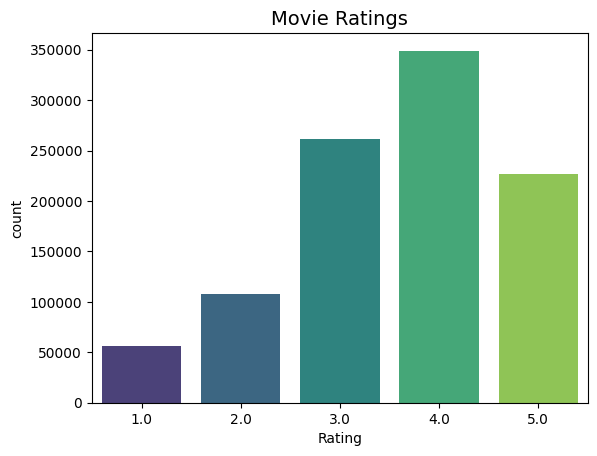

In [110]:
sns.countplot(x='Rating',data=df,palette="viridis")
plt.title('Movie Ratings', fontsize = 14)
plt.show()

Non uniform distribution

In [111]:
print(f"Mean rating: {round(df['Rating'].mean(),2)}.")

Mean rating: 3.58.


In [112]:
mean_ratings = df.groupby('UserID')['Rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean rating per user: 3.7.


In [113]:
movie_ratings = df2.merge(df1, on='MovieID')
movie_ratings['Title'].value_counts()[0:10]

American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: Title, dtype: int64

Recommendation

In [115]:
df.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Animation,...,Children's,War,Romance,Thriller,Documentary,Fantasy,Crime,Sci-Fi,Film-Noir,Comedy
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,1,...,1,0,0,0,0,0,0,0,0,1
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,1,...,1,0,1,0,0,0,0,0,0,0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,0,...,0,0,0,0,0,1,0,1,0,0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,1,0,0,0,0,0,0,0,0


In [116]:
df.columns

Index(['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code', 'MovieID', 'Title',
       'Rating', 'Timestamp', 'Animation', 'Horror', 'Action', 'Mystery',
       'Adventure', 'Musical', 'Western', 'Drama', 'Children's', 'War',
       'Romance', 'Thriller', 'Documentary', 'Fantasy', 'Crime', 'Sci-Fi',
       'Film-Noir', 'Comedy'],
      dtype='object')

In [119]:
df['Gender'] = df['Gender'].replace({'M': 1, 'F': 0})

In [120]:
df.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Animation,...,Children's,War,Romance,Thriller,Documentary,Fantasy,Crime,Sci-Fi,Film-Noir,Comedy
0,1.0,0,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,1,...,1,0,0,0,0,0,0,0,0,1
1,1.0,0,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,1,...,1,0,1,0,0,0,0,0,0,0
2,1.0,0,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,0,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,0,...,0,0,0,0,0,1,0,1,0,0
4,1.0,0,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,1,0,0,0,0,0,0,0,0


In [121]:
k_means_df = df.drop(columns=['Timestamp', 'Zip-code'])

In [122]:
k_means_df

,UserID,Gender,Age,Occupation,MovieID,Title,Rating,Animation,Horror,Action,...,Children's,War,Romance,Thriller,Documentary,Fantasy,Crime,Sci-Fi,Film-Noir,Comedy
0,1.0,0,1.0,10.0,1,Toy Story (1995),5.0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
1,1.0,0,1.0,10.0,48,Pocahontas (1995),5.0,1,0,0,...,1,0,1,0,0,0,0,0,0,0
2,1.0,0,1.0,10.0,150,Apollo 13 (1995),5.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,0,1.0,10.0,260,Star Wars: Episode IV - A New Hope (1977),4.0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
4,1.0,0,1.0,10.0,527,Schindler's List (1993),5.0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,1,25.0,6.0,3683,Blood Simple (1984),4.0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1000205,6040.0,1,25.0,6.0,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),4.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1000206,6040.0,1,25.0,6.0,3735,Serpico (1973),4.0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1000207,6040.0,1,25.0,6.0,3751,Chicken Run (2000),4.0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
